# Base ARSS — Paper-Faithful Implementation on tgbl-uci

**Honours Project Phase I | IIIT Kottayam**

---

## Overview

This notebook implements the **Base ARSS** model exactly as described in:
> *Anonymous Reweighted Subgraph Sampling-based Graph Neural Networks for Link Prediction*  
> Zhang et al., Chaos, Solitons and Fractals, 2026

### Dataset: tgbl-uci (UC Irvine Online Messages)

The paper evaluates on **Cora and Citeseer** (static graphs). Here we apply ARSS to the **tgbl-uci** dataset from the Temporal Graph Benchmark — a real-world homogeneous temporal graph of private messages sent between students on a UC Irvine online platform.

- **1,899 nodes** (all users — homogeneous, person→person)
- **~59,835 timestamped messages**
- **No edge features** (unlike Wikipedia JODIE)
- Split **chronologically** (70/15/15%) to prevent data leakage

**Why tgbl-uci over Wikipedia JODIE?** Wikipedia JODIE is bipartite (users vs pages), which means two nodes of the same type never share a first-order common neighbour. This silently zeroes out the common-neighbour term in the ARSS link representation `z_ij = h_i ⊙ h_j || sum(h_u)` for every single prediction. On tgbl-uci, users can message any other user, so common neighbours (mutual contacts) naturally exist and the full `z_ij` representation actually fires.

**Crucially, timestamps are ignored by the model.** Base ARSS treats the training edges as a static graph and uses only structural (degree/topology) information for sampling and prediction. The timestamps only determine the train/val/test split. This is the baseline against which Temporal ARSS (Phase II) will be compared.

### What makes this paper-faithful?

| Paper component | This implementation |
|---|---|
| Reweighted similarity `w_ik` (Eq. 2-4) | Exact formula: popularity score + attraction score |
| Breadth-then-depth sampling (Eq. 5) | Full implementation: all 1-hop first, then depth |
| Anonymous subgraphs | Node labels stripped; 5 structural roles assigned |
| Message passing (Eq. 6-7) | GraphSAGE on subgraph + mean pooling |
| Link representation (Eq. 8) | `h_i ⊙ h_j` (Hadamard) concat with common neighbor sum |
| Link predictor (Eq. 9) | MLP + sigmoid |

### Pipeline

```
tgbl-uci (~60K timestamped user→user messages)
         |
         v
Chronological train/val/test split (70/15/15%)
         |
         v
Build STATIC graph from training edges only (ignore timestamps)
         |
         v
Precompute w_ik for all 1-hop neighbour pairs in training graph (Eq. 2-4)
         |
         v
For each (u, v) edge in batch:
   1. Breadth-then-depth sampling -> K neighbors per node (Eq. 5)
   2. Build anonymous subgraph (strip node labels, assign roles)
   3. GraphSAGE message passing -> node embeddings (Eq. 6-7)
   4. z_ij = h_i ⊙ h_j || sum(h_u)  (Eq. 8)
   5. MLP -> sigmoid -> link probability (Eq. 9)
         |
         v
Evaluate with AUC and Average Precision
```


---
## Cell 1 — Imports and Device Setup

Requires `py-tgb` in addition to the standard stack:
```
pip install py-tgb
```


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import time
import os
import matplotlib.pyplot as plt
from collections import defaultdict
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data, Batch
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


---
## Cell 2 — Dataset: tgbl-uci

### Dataset

**tgbl-uci** is a supplementary dataset from the Temporal Graph Benchmark (TGB):

- **~1,899 nodes** (university students, all of the same type — homogeneous)
- **~59,835 timestamped messages** (directed user→user private messages)
- **No edge features** — the model uses only graph structure
- Source: UC Irvine online social network, originally from Opsahl (2009)

This is a **homogeneous** graph — both endpoints of every edge are users, so two users
can share mutual contacts as common neighbours. This makes the common-neighbour term
in the ARSS link representation (`sum(h_u)` in Eq. 8) non-zero for the first time,
exercising the full model as designed.

### Chronological split prevents data leakage

```
Timeline:  |------ Train (70%) ------|-- Val (15%) --|-- Test (15%) --|
           t=0                       t1              t2             t_max
```

The static graph is built from **training edges only**. Val/test edges are used only
as positive examples during evaluation.

**Base ARSS is entirely timestamp-agnostic** — timestamps determine the split only.

### Loading via py-tgb

tgbl-uci is loaded from TGB rather than PyG's JODIEDataset. The `LinkPropPredDataset`
loader returns numpy arrays directly: `sources`, `destinations`, `timestamps`.
Since there are no edge features, `msg` is omitted entirely.


In [2]:
from tgb.linkproppred.dataset import LinkPropPredDataset

# ── Load tgbl-uci ─────────────────────────────────────────────────────────────
dataset   = LinkPropPredDataset(name='tgbl-uci', root='./data', preprocess=True)
full_data = dataset.full_data   # dict with 'sources', 'destinations', 'timestamps'

src_all = full_data['sources'].astype(np.int64)        # [E]
dst_all = full_data['destinations'].astype(np.int64)   # [E]
t_all   = full_data['timestamps'].astype(np.float64)   # [E]

NUM_NODES = int(max(src_all.max(), dst_all.max())) + 1
print(f'Nodes      : {NUM_NODES:,}')
print(f'Edges      : {len(src_all):,}')
print(f'Time range : [{t_all.min():.0f}, {t_all.max():.0f}]')

# ── Chronological 70/15/15 split ─────────────────────────────────────────────
n      = len(src_all)
val_t  = t_all[int(n * 0.70)]
test_t = t_all[int(n * 0.85)]

train_mask = t_all <  val_t
val_mask   = (t_all >= val_t) & (t_all < test_t)
test_mask  = t_all >= test_t

train_src = src_all[train_mask];  train_dst = dst_all[train_mask];  train_t = t_all[train_mask]
val_src   = src_all[val_mask];    val_dst   = dst_all[val_mask];    val_t_arr = t_all[val_mask]
test_src  = src_all[test_mask];   test_dst  = dst_all[test_mask];   test_t_arr = t_all[test_mask]

print(f'Train      : {len(train_src):,}')
print(f'Val        : {len(val_src):,}')
print(f'Test       : {len(test_src):,}')

# ── Degree stats on training graph ───────────────────────────────────────────
from collections import Counter
deg = Counter(train_src.tolist() + train_dst.tolist())
print(f'\nTrain degree stats (undirected view)')
print(f'  Mean={np.mean(list(deg.values())):.1f}, Max={max(deg.values())}')

# ── No edge features in tgbl-uci — no normalisation needed ───────────────────
EDGE_FEAT_DIM = 0
print(f'Edge features: none (homogeneous message network)')


Download started, this might take a while . . . 
Dataset title: tgbl-uci
Download completed 
Dataset directory is  c:\Users\hp\Documents\GitHub\temporal-arss(honours project)\venv\Lib\site-packages\tgb/./data\tgbl_uci
file not processed, generating processed file
Nodes      : 3,799
Edges      : 59,835
Time range : [0, 16736181]
Train      : 41,884
Val        : 8,975
Test       : 8,976

Train degree stats (undirected view)
  Mean=33.1, Max=998
Edge features: none (homogeneous message network)


---
## Cell 3 — Static Graph Construction + Reweighted Similarity (Equations 2-4)

Base ARSS treats the training data as a **static undirected graph**. We build the adjacency list and precompute all `w_ik` values.

### The reweighting formula

For nodes `v_i` and neighbor `v_k`:

**Equation (2):** `w_ik = 2 * pi_ik / (1 + eta_ik)`

**Equation (3) — Popularity score:**
`pi_ik = (psi(d_i) + psi(d_k)) / (2 * psi(d_max))`, where `psi(x) = log(1+x)`

**Equation (4) — Attraction score:**
`eta_ik = 1 - prod_{v_u in N(v_i) & N(v_k)} [psi(d_u) / psi(d_max)]`

**Lower `w_ik` = more structurally similar = higher priority in sampling.**

Intuition: nodes that share many high-degree common neighbors are less distinctive (high-degree nodes connect to everyone), so their `eta_ik` is large, pushing `w_ik` down — counterintuitively making them MORE similar. Nodes connected only through low-degree hubs are more meaningfully related.

### Why precompute?

Subgraph sampling happens for every edge in every batch. Precomputing all training-edge `w_ik` values upfront eliminates repeated computation of the same neighbor pairs.

In [3]:
# Build static adjacency from training edges
adj    = defaultdict(set)
for u, v in zip(train_src.tolist(), train_dst.tolist()):
    adj[u].add(v)
    adj[v].add(u)

degree   = {n: len(nb) for n, nb in adj.items()}
d_max    = max(degree.values()) if degree else 1

def psi(x: float) -> float:
    """Log-nonlinearity from the paper: psi(x) = log(1+x)"""
    return math.log(1.0 + x)

psi_dmax = psi(d_max)

def compute_w_ik(i: int, k: int) -> float:
    """
    Reweighted similarity w_ik between v_i and neighbor v_k.
    Implements Equations (2)-(4) exactly as in the paper.
    Lower value = more topologically similar = higher sampling priority.
    """
    d_i = degree.get(i, 0)
    d_k = degree.get(k, 0)

    # Equation (3): popularity score
    pi_ik = (psi(d_i) + psi(d_k)) / (2.0 * psi_dmax)

    # Equation (4): attraction from common neighbors
    common = adj.get(i, set()) & adj.get(k, set())
    if common:
        prod   = math.prod(psi(degree.get(u, 1)) / psi_dmax for u in common)
        eta_ik = 1.0 - prod
    else:
        eta_ik = 0.0  # no common neighbors

    # Equation (2)
    return (2.0 * pi_ik) / (1.0 + eta_ik)

# Precompute w_ik for ALL 1-hop neighbour pairs in training graph
# Covers adjacency pairs beyond just direct training edges, eliminating
# expensive on-the-fly compute_w_ik calls during sampling (set intersections).
print('Precomputing reweighted similarities for all 1-hop pairs...')
t0      = time.time()
w_cache = {}   # (i, k) -> float, symmetric

for node, neighbours in adj.items():
    for nb in neighbours:
        if (node, nb) not in w_cache:
            w = compute_w_ik(node, nb)
            w_cache[(node, nb)] = w
            w_cache[(nb, node)] = w

print(f'Done: {len(w_cache):,} pairs in {time.time()-t0:.1f}s')
print(f'Static graph : {len(adj):,} nodes, {sum(len(nb) for nb in adj.values())//2:,} undirected edges')
print(f'(Homogeneous: common neighbours between any two users can now exist)')

# Sanity check: show top neighbors by similarity for a sample node
sample_node = int(train_src[0])
ranked_nb   = sorted(adj[sample_node],
                     key=lambda k: w_cache.get((sample_node, k), compute_w_ik(sample_node, k)))
print(f'\nExample node {sample_node} (degree={degree[sample_node]})')
print(f'  Most similar neighbors (lowest w_ik):')
for nb in ranked_nb[:3]:
    w = w_cache.get((sample_node, nb), compute_w_ik(sample_node, nb))
    print(f'    node {nb:4d}  degree={degree.get(nb,0):4d}  w={w:.4f}')

Precomputing reweighted similarities for all 1-hop pairs...


Done: 28,762 pairs in 0.0s
Static graph : 2,533 nodes, 14,381 undirected edges
(Homogeneous: common neighbours between any two users can now exist)

Example node 1 (degree=17)
  Most similar neighbors (lowest w_ik):
    node 2059  degree=   1  w=0.6738
    node 2155  degree=   1  w=0.6738
    node 2297  degree=   1  w=0.6738


---
## Cell 4 — Breadth-then-Depth Subgraph Sampling (Equation 5)

The paper's sampling strategy (Section 2.3):

```
h=1 (breadth):
  candidates = N^1(v_i)  [direct neighbors]
  if |candidates| <= K:   take ALL  <- breadth: capture full local structure
  if |candidates| > K:    rank by w_ik, take top K  <- reweighted selection

h=2 (depth, only if selected < K):
  candidates = N^2(v_i) \ already_selected
  rank by w_ik, fill remaining budget

... repeat until K nodes selected or no more candidates
```

Equation (5) formalizes this as:
- `|Omega^(h-1)| + |N^h| <= K` : take all h-hop neighbors
- `|Omega^(h-1)| + |N^h| > K`  : take top `K - |Omega^(h-1)|` by w_ik

In [4]:
def sample_subgraph_nodes(v_i: int, K: int, adj: dict, w_cache: dict,
                           max_hops: int = 2) -> list:
    """
    Breadth-then-depth subgraph sampling (Equation 5).

    Returns list of up to K neighbor node IDs for target node v_i,
    prioritizing structurally close nodes (lowest w_ik).
    """
    selected     = []
    selected_set = set()
    visited      = {v_i}
    frontier     = adj.get(v_i, set()).copy()

    for _ in range(1, max_hops + 1):
        candidates = frontier - selected_set - {v_i}
        if not candidates:
            break

        remaining = K - len(selected)
        if remaining <= 0:
            break

        # Rank by w_ik ascending (most similar = lowest score = sampled first)
        def w_score(k):
            key = (v_i, k)
            return w_cache[key] if key in w_cache else compute_w_ik(v_i, k)

        ranked = sorted(candidates, key=w_score)

        if len(candidates) <= remaining:
            batch = ranked          # breadth: take all
        else:
            batch = ranked[:remaining]   # depth: fill budget

        selected.extend(batch)
        selected_set.update(batch)
        visited.update(batch)

        if len(selected) >= K:
            break

        # Expand frontier to next hop
        frontier = set()
        for nd in selected_set:
            frontier |= adj.get(nd, set())
        frontier -= visited

    return selected[:K]


# Sanity check
K_test   = 10
node     = int(train_src[0])
sampled  = sample_subgraph_nodes(node, K_test, adj, w_cache)
n1_count = len(adj.get(node, set()))

print(f'Breadth-then-depth sampling check')
print(f'  Target node  : {node}  (degree={degree.get(node,0)}, 1-hop={n1_count})')
print(f'  K={K_test}, sampled={len(sampled)}')
in_1hop = sum(1 for n in sampled if n in adj.get(node, set()))
print(f'  From 1-hop   : {in_1hop}')
print(f'  From deeper  : {len(sampled) - in_1hop}')

Breadth-then-depth sampling check
  Target node  : 1  (degree=17, 1-hop=17)
  K=10, sampled=10
  From 1-hop   : 10
  From deeper  : 0


---
## Cell 5 — Anonymous Subgraph Builder

For a target pair `(u, v)`, after sampling neighbors `u_nb` and `v_nb`, we build an **anonymous subgraph** by:

1. **Stripping node IDs** — all nodes become anonymous
2. **Assigning structural roles** (one-hot features):

| Role | ID | Meaning |
|---|---|---|
| Source | 0 | `u` |
| Target | 1 | `v` |
| Common neighbor | 2 | in `N(u) ∩ N(v)` |
| Source-only | 3 | in `N(u)` only |
| Target-only | 4 | in `N(v)` only |

3. **Adding bidirectional edges** between each target and its sampled neighbors
4. **Flagging common neighbors** via `common_mask` (used in Equation 8)

### Why anonymize?
Without anonymization, the GNN cannot distinguish automorphic nodes (structurally identical nodes with different IDs). Stripping IDs forces the model to rely purely on local topology, improving generalization.

In [5]:
NUM_ROLES = 5   # source, target, common, src-only, dst-only

def build_anonymous_subgraph(u: int, v: int,
                              u_neighbors: list,
                              v_neighbors: list) -> Data:
    """
    Build anonymous subgraph for target pair (u, v).

    Node layout: [u=0, v=1, ...rest...]
    Node features x: one-hot structural role [N, 5]
    common_mask: boolean [N] flagging common neighbors
    """
    u_set  = set(u_neighbors)
    v_set  = set(v_neighbors)
    common = u_set & v_set

    all_nodes = [u, v] + list(u_set | v_set)
    n2l = {n: i for i, n in enumerate(all_nodes)}
    N   = len(all_nodes)

    # Structural role assignment
    roles    = torch.zeros(N, dtype=torch.long)
    roles[0] = 0   # source
    roles[1] = 1   # target
    for nd in all_nodes[2:]:
        if nd in common:
            roles[n2l[nd]] = 2
        elif nd in u_set:
            roles[n2l[nd]] = 3
        else:
            roles[n2l[nd]] = 4

    x = F.one_hot(roles, num_classes=NUM_ROLES).float()  # [N, 5]

    # Bidirectional edges
    esrc, edst = [], []
    for nb in u_neighbors:
        a, b = n2l[u], n2l[nb]; esrc += [a, b]; edst += [b, a]
    for nb in v_neighbors:
        a, b = n2l[v], n2l[nb]; esrc += [a, b]; edst += [b, a]

    if esrc:
        edge_index = torch.tensor([esrc, edst], dtype=torch.long)
    else:
        edge_index = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, common_mask=(roles == 2))


# Sanity check
u_ex  = int(train_src[0])
v_ex  = int(train_dst[0])
u_nb  = sample_subgraph_nodes(u_ex, K=8, adj=adj, w_cache=w_cache)
v_nb  = sample_subgraph_nodes(v_ex, K=8, adj=adj, w_cache=w_cache)
sg    = build_anonymous_subgraph(u_ex, v_ex, u_nb, v_nb)

role_counts = sg.x.argmax(1).bincount(minlength=5)
print(f'Anonymous subgraph for edge ({u_ex}, {v_ex})')
print(f'  Nodes: {sg.num_nodes}, Edges: {sg.edge_index.shape[1]}')
for name, cnt in zip(['source','target','common','src-only','dst-only'], role_counts):
    print(f'  {name:12s}: {cnt.item()}')

Anonymous subgraph for edge (1, 1902)
  Nodes: 15, Edges: 32
  source      : 1
  target      : 1
  common      : 3
  src-only    : 5
  dst-only    : 5


---
## Cell 6 — GNN Encoder and Link Predictor (Equations 6-9)

### GNN Encoder (Equations 6-7)

GraphSAGE runs `L` message-passing rounds within each anonymous subgraph. After `L` layers, the target node embedding is obtained by **mean pooling** over all nodes in the subgraph.

### Link Representation (Equation 8)

```
z_ij = (h_i ⊙ h_j) || sum_{v_u in N(v_i) ∩ N(v_j)} h_u
```

The **Hadamard product** `h_i ⊙ h_j` captures element-wise feature agreement between the two target nodes. The **sum of common neighbor embeddings** provides structural discrimination — nodes with different features as common neighbors lead to different sums, helping the model distinguish pairs with similar structure but different contexts.

### Link Predictor (Equation 9)

```
E_hat_ij = sigmoid(MLP(z_ij))
```

Input dim = emb_dim (Hadamard) + emb_dim (common neighbor sum) = 2 * emb_dim

In [6]:
class SubgraphGNN(nn.Module):
    """L-layer GraphSAGE on anonymous subgraphs. Implements Equations (6)-(7)."""

    def __init__(self, in_ch: int = NUM_ROLES, hidden: int = 128,
                 out: int = 64, layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.dropout = dropout
        dims = [in_ch] + [hidden] * (layers - 1) + [out]
        self.convs = nn.ModuleList(
            [SAGEConv(dims[i], dims[i+1]) for i in range(layers)]
        )
        self.norms = nn.ModuleList(
            [nn.LayerNorm(dims[i+1]) for i in range(layers)]
        )

    def forward(self, x, edge_index):
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x   # [N_total, out]


class LinkPredictor(nn.Module):
    """
    MLP predicting link probability from z_ij = [h_i x h_j || sum(h_u)].
    Implements Equations (8)-(9).
    Input dim = emb_dim * 2 (Hadamard + common neighbor sum).
    """

    def __init__(self, emb_dim: int = 64, hidden: int = 64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, h_i, h_j, h_common):
        # Equation (8): z_ij = h_i ⊙ h_j || sum(h_u)
        hadamard = h_i * h_j
        z_ij     = torch.cat([hadamard, h_common], dim=-1)
        return self.mlp(z_ij).squeeze(-1)   # [B] logits


class ARSSModel(nn.Module):
    """
    Base ARSS: paper-faithful, no temporal components.
    Subgraph sampling is done outside (precomputed w_ik).
    The model receives pre-built anonymous subgraphs.
    """

    def __init__(self, hidden: int = 128, emb_dim: int = 64,
                 gnn_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.gnn       = SubgraphGNN(NUM_ROLES, hidden, emb_dim, gnn_layers, dropout)
        self.predictor = LinkPredictor(emb_dim, hidden)
        self.emb_dim   = emb_dim

    def forward(self, subgraphs: list) -> torch.Tensor:
        """subgraphs: list of B Data objects. Returns logits [B]."""
        B      = len(subgraphs)
        device = next(self.parameters()).device

        # Batch all subgraphs into one disconnected graph for a single GNN call
        batch    = Batch.from_data_list(subgraphs).to(device)
        all_embs = self.gnn(batch.x, batch.edge_index)   # [N_total, D]

        # Target node embeddings (positions 0 and 1 in each subgraph)
        starts = batch.ptr[:-1]       # [B] start index per subgraph
        h_i    = all_embs[starts]     # [B, D] source
        h_j    = all_embs[starts + 1] # [B, D] target

        # Equation (8): sum of common neighbor embeddings
        h_common = torch.zeros(B, self.emb_dim, device=device)
        for idx, sg in enumerate(subgraphs):
            cm = sg.common_mask
            if cm.any():
                start         = batch.ptr[idx].item()
                sg_embs       = all_embs[start: start + sg.num_nodes]
                h_common[idx] = sg_embs[cm.to(device)].sum(dim=0)

        return self.predictor(h_i, h_j, h_common)   # [B]


model    = ARSSModel(hidden=128, emb_dim=64, gnn_layers=2, dropout=0.3).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'ARSS parameters: {n_params:,}')
print(model)

ARSS parameters: 43,073
ARSSModel(
  (gnn): SubgraphGNN(
    (convs): ModuleList(
      (0): SAGEConv(5, 128, aggr=mean)
      (1): SAGEConv(128, 64, aggr=mean)
    )
    (norms): ModuleList(
      (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (predictor): LinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


---
## Cell 7 — Training Configuration

| Parameter | Value | Note |
|---|---|---|
| K | 10 | Subgraph budget per target node |
| L (GNN layers) | 2 | Two GraphSAGE layers: 5 → 128 → 64 |
| BATCH_SIZE | 512 | |
| EPOCHS | 15 | |
| LR | 3e-4 | Adam with weight decay 1e-5 |
| LR scheduler | CosineAnnealingLR | T_max = EPOCHS |

The static graph (`adj`, `w_cache`) never changes during training — Base ARSS has no temporal state to update.

No `N_USERS` offset is needed here: tgbl-uci is homogeneous so all node IDs live in a single shared space `[0, NUM_NODES)`.


In [7]:
K              = 10
BATCH_SIZE     = 512
EPOCHS         = 15
LR             = 3e-4
VALIDATE_EVERY = 3

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
rng = np.random.default_rng(SEED)


def get_batches(src_arr, dst_arr, batch_size: int):
    n = len(src_arr)
    for s in range(0, n, batch_size):
        yield src_arr[s:min(s+batch_size, n)], dst_arr[s:min(s+batch_size, n)]


def negative_sample(src, n_nodes: int) -> np.ndarray:
    """Random negative destination — uniform over all nodes (homogeneous graph, no offset needed)."""
    return rng.integers(0, n_nodes, size=len(src))


def bce_loss(pos_logits, neg_logits):
    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
    return F.binary_cross_entropy_with_logits(logits, labels)


def build_batch_subgraphs(src_batch, dst_batch, K, adj, w_cache) -> list:
    """Sample and build anonymous subgraphs for each (u,v) pair."""
    subgraphs = []
    for u, v in zip(src_batch.tolist(), dst_batch.tolist()):
        u_nb = sample_subgraph_nodes(u, K, adj, w_cache)
        v_nb = sample_subgraph_nodes(v, K, adj, w_cache)
        subgraphs.append(build_anonymous_subgraph(u, v, u_nb, v_nb))
    return subgraphs


print(f'Config: K={K}, batch={BATCH_SIZE}, epochs={EPOCHS}, lr={LR}')
print(f'Batches per epoch: {math.ceil(len(train_src)/BATCH_SIZE)}')

Config: K=10, batch=512, epochs=15, lr=0.0003
Batches per epoch: 82


---
## Cell 8 — Evaluation Function

In [8]:
@torch.no_grad()
def evaluate(model, src_arr, dst_arr, adj, w_cache, K, n_nodes):
    """
    Returns (AUC, AP) on a data split.
    The static graph (adj, w_cache) is always the training graph.
    """
    model.eval()
    all_scores, all_labels = [], []

    for src_b, dst_b in get_batches(src_arr, dst_arr, BATCH_SIZE):
        neg_dst = negative_sample(src_b, n_nodes)

        pos_sgs = build_batch_subgraphs(src_b, dst_b,  K, adj, w_cache)
        neg_sgs = build_batch_subgraphs(src_b, neg_dst, K, adj, w_cache)

        pos_logits = model(pos_sgs)
        neg_logits = model(neg_sgs)

        scores = torch.cat([pos_logits, neg_logits]).sigmoid().cpu().numpy()
        labels = np.array([1]*len(pos_logits) + [0]*len(neg_logits))

        all_scores.append(scores)
        all_labels.append(labels)

    all_scores = np.concatenate(all_scores)
    all_labels = np.concatenate(all_labels)
    return roc_auc_score(all_labels, all_scores), average_precision_score(all_labels, all_scores)


print('Evaluation function ready')

Evaluation function ready


---
## Cell 9 — Training Loop

In [9]:
os.makedirs('./checkpoints', exist_ok=True)

train_losses = []
val_aucs, val_aps, val_epochs = [], [], []
best_val_auc = 0.0

for epoch in range(1, EPOCHS + 1):
    t_epoch = time.time()
    model.train()
    epoch_loss, n_batches = 0.0, 0

    for src_b, dst_b in get_batches(train_src, train_dst, BATCH_SIZE):
        neg_dst = negative_sample(src_b, NUM_NODES)

        pos_sgs = build_batch_subgraphs(src_b, dst_b,  K, adj, w_cache)
        neg_sgs = build_batch_subgraphs(src_b, neg_dst, K, adj, w_cache)

        pos_logits = model(pos_sgs)
        neg_logits = model(neg_sgs)

        loss = bce_loss(pos_logits, neg_logits)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    t_train = time.time() - t_epoch

    val_auc, val_ap = evaluate(
        model, val_src, val_dst, adj, w_cache, K, NUM_NODES
    )
    val_aucs.append(val_auc)
    val_aps.append(val_ap)
    val_epochs.append(epoch)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), './checkpoints/arss_base_best.pt')
        tag = '  [best]'
    else:
        tag = ''

    t_total = time.time() - t_epoch
    print(f'Epoch {epoch:02d} | Loss {avg_loss:.4f} | '
            f'Val AUC {val_auc:.4f} | Val AP {val_ap:.4f} | '
            f'Train {t_train:.0f}s | Total {t_total:.0f}s{tag}')

print('\nTraining complete!')

Epoch 01 | Loss 0.5789 | Val AUC 0.6002 | Val AP 0.5828 | Train 58s | Total 70s  [best]
Epoch 02 | Loss 0.5022 | Val AUC 0.5999 | Val AP 0.6085 | Train 66s | Total 77s
Epoch 03 | Loss 0.4945 | Val AUC 0.5980 | Val AP 0.6087 | Train 65s | Total 76s
Epoch 04 | Loss 0.4907 | Val AUC 0.5898 | Val AP 0.6083 | Train 66s | Total 78s
Epoch 05 | Loss 0.4843 | Val AUC 0.5956 | Val AP 0.6095 | Train 68s | Total 79s
Epoch 06 | Loss 0.4765 | Val AUC 0.5876 | Val AP 0.6007 | Train 67s | Total 78s
Epoch 07 | Loss 0.4661 | Val AUC 0.5955 | Val AP 0.6046 | Train 66s | Total 77s
Epoch 08 | Loss 0.4570 | Val AUC 0.5948 | Val AP 0.6020 | Train 67s | Total 80s
Epoch 09 | Loss 0.4535 | Val AUC 0.6083 | Val AP 0.6037 | Train 70s | Total 83s  [best]
Epoch 10 | Loss 0.4490 | Val AUC 0.6088 | Val AP 0.6050 | Train 68s | Total 79s  [best]
Epoch 11 | Loss 0.4475 | Val AUC 0.6022 | Val AP 0.6003 | Train 71s | Total 84s
Epoch 12 | Loss 0.4446 | Val AUC 0.6087 | Val AP 0.6042 | Train 72s | Total 85s
Epoch 13 | Loss 

---
## Cell 10 — Training Curves

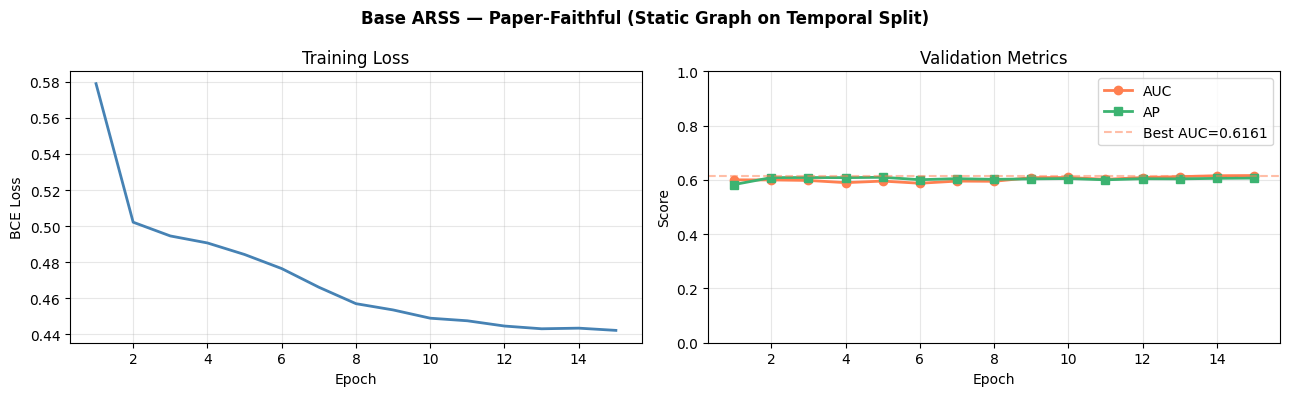

Best validation AUC: 0.6161


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(train_losses) + 1)

axes[0].plot(ep, train_losses, color='steelblue', linewidth=2)
axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='BCE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_epochs, val_aucs, 'o-', label='AUC',
             color='coral', linewidth=2)
axes[1].plot(val_epochs, val_aps,  's-', label='AP',
             color='mediumseagreen', linewidth=2)
axes[1].axhline(y=best_val_auc, color='coral', linestyle='--',
                alpha=0.5, label=f'Best AUC={best_val_auc:.4f}')
axes[1].set(title='Validation Metrics', xlabel='Epoch',
            ylabel='Score', ylim=(0, 1))
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Base ARSS — Paper-Faithful (Static Graph on Temporal Split)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('arss_base_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best validation AUC: {best_val_auc:.4f}')

---
## Cell 11 — Final Test Evaluation

In [11]:
model.load_state_dict(torch.load('./checkpoints/arss_base_best.pt', map_location=DEVICE))

test_auc, test_ap = evaluate(
    model, test_src, test_dst, adj, w_cache, K, NUM_NODES
)

print('=' * 44)
print('  Base ARSS — Final Test Results')
print('  (paper-faithful, static graph, tgbl-uci)')
print('=' * 44)
print(f'  AUC : {test_auc:.4f}')
print(f'  AP  : {test_ap:.4f}')
print('=' * 44)
print()
print('Phase I complete. This is your baseline.')
print('Phase II: Temporal ARSS will add recency decay')
print('to w_ik to beat these numbers.')

  Base ARSS — Final Test Results
  (paper-faithful, static graph, tgbl-uci)
  AUC : 0.5305
  AP  : 0.5422

Phase I complete. This is your baseline.
Phase II: Temporal ARSS will add recency decay
to w_ik to beat these numbers.


---
## Cell 12 — K Ablation

Evaluates the trained model at different subgraph sizes K = {5, 10, 15, 20, 25}, without retraining.
Shows how sensitive link prediction performance is to the neighbourhood budget on Wikipedia JODIE.


   K   Val AUC    Val AP
   5    0.5905    0.5745
  10    0.6148    0.6055
  15    0.6192    0.6185
  20    0.6261    0.6316
  25    0.6256    0.6359


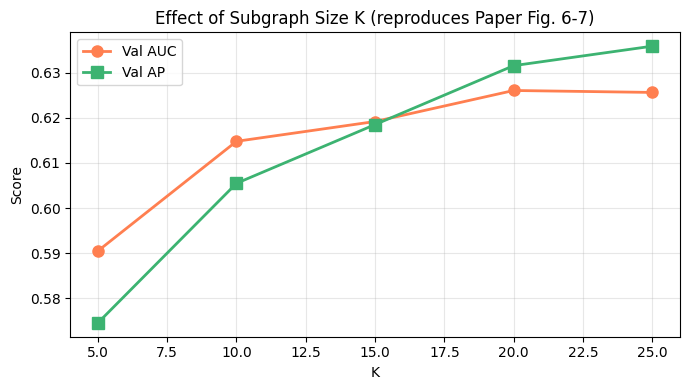

In [12]:
model.load_state_dict(torch.load('./checkpoints/arss_base_best.pt', map_location=DEVICE))

K_values    = [5, 10, 15, 20, 25]
k_auc_vals  = []
k_ap_vals   = []

print(f'{"K":>4}  {"Val AUC":>8}  {"Val AP":>8}')
for k_val in K_values:
    auc_k, ap_k = evaluate(model, val_src, val_dst, adj, w_cache,
                           k_val, NUM_NODES)
    k_auc_vals.append(auc_k); k_ap_vals.append(ap_k)
    print(f'{k_val:>4}  {auc_k:>8.4f}  {ap_k:>8.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_values, k_auc_vals, 'o-', color='coral',
        label='Val AUC', linewidth=2, markersize=8)
ax.plot(K_values, k_ap_vals,  's-', color='mediumseagreen',
        label='Val AP',  linewidth=2, markersize=8)
ax.set(title='Effect of Subgraph Size K (reproduces Paper Fig. 6-7)',
       xlabel='K', ylabel='Score')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arss_base_k_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

### What was implemented

Paper-faithful Base ARSS on **tgbl-uci**:

- **Eq. 2-4**: Exact `w_ik` reweighting via popularity + attraction scores (node degrees, common neighbors)
- **Eq. 5**: Breadth-then-depth subgraph sampling — 1-hop first, then deeper to fill budget K
- **Anonymous subgraphs**: 5 structural roles (source / target / common / src-only / dst-only)
- **Eq. 6-7**: GraphSAGE message passing + mean pooling for target node embeddings
- **Eq. 8**: `z_ij = (h_i ⊙ h_j) || sum(h_u)` — Hadamard product + common neighbor sum
- **Eq. 9**: MLP + sigmoid link predictor

### Dataset

tgbl-uci (UC Irvine online messages): 1,899 users, ~59,835 timestamped messages.
Homogeneous graph — common neighbours exist between any two users, so the full link
representation fires for the first time. Timestamps used only for chronological splitting (70/15/15%).

### What Phase II (Temporal ARSS) changes

Only the neighbour scoring function needs extending:

```python
# Phase II: multiply structural similarity by recency penalty
dt = t_query - t_last_interaction(i, k)
w_ik_temporal = w_ik_base * exp(+lambda * dt / T_SCALE)
```

Higher `w_ik_temporal` = lower sampling priority, so older edges are deprioritised.
The anonymous subgraph builder, GNN encoder, and link predictor are identical in both phases.
The test AUC/AP from this notebook is the Phase II target to beat.
